## Part 1

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix
from imblearn.over_sampling import SMOTE

### Load the dataset

In [4]:
dataset_path = "./defect_dataset-ant-1.3.xlsx"
df = pd.read_excel(dataset_path)

### Drop non-numeric columns

In [5]:
df_numeric = df.drop(columns=['name', 'version', 'name.1'])

## Data Exploration and Visualization
Printing the first few rows helps in understanding the dataset structure, feature names, and target variable alignment.

In [6]:
print("First two rows of the dataset:")
print(df_numeric.head(2))

First two rows of the dataset:
   wmc  dit  noc  cbo  rfc  lcom  ca  ce  npm  lcom3  ...  dam  moa       mfa  \
0   11    4    2   14   42    29   2  12    5  0.725  ...  1.0    1  0.885057   
1    3    2    0    1    9     0   0   1    1  0.000  ...  1.0    1  0.714286   

        cam  ic  cbm        amc  max_cc  avg_cc  bug  
0  0.232323   3    4  34.545455       3  1.2727    0  
1  0.666667   1    1  17.333333       1  0.6667    0  

[2 rows x 21 columns]


### Correlation Heatmap
Helps in understanding the relationships between features and identifying highly correlated features for feature selection.

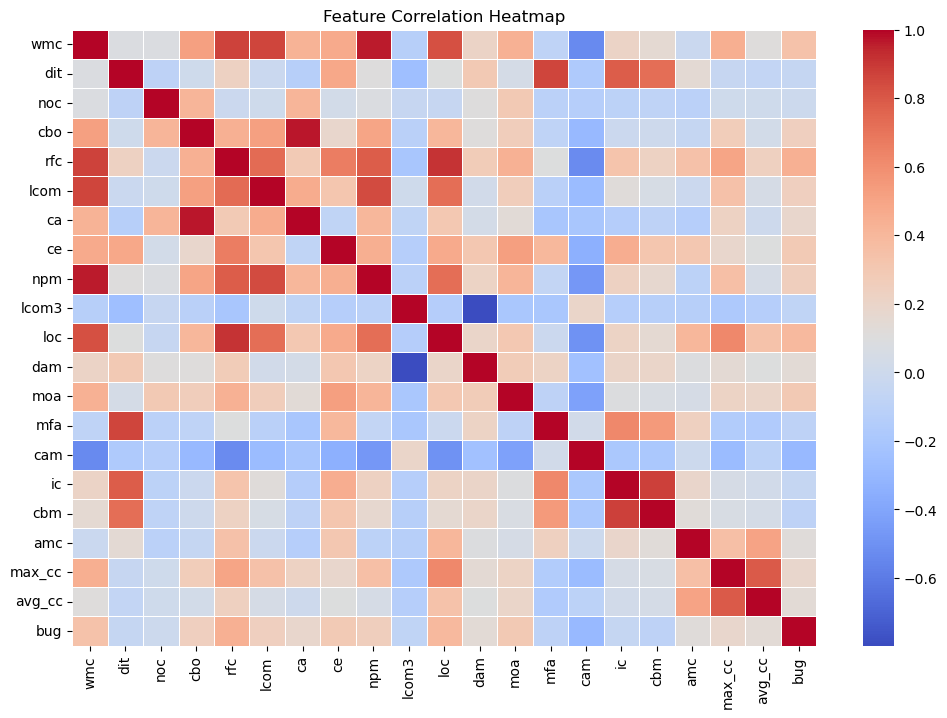

In [7]:
plt.figure(figsize=(12, 8))
sns.heatmap(df_numeric.corr(), annot=False, cmap="coolwarm", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

## Data Preprocessing and Cleaning
Missing values can lead to errors in model training, and outliers may distort model performance.

In [8]:
print("\nMissing Values:")
print(df_numeric.isnull().sum())


Missing Values:
wmc       0
dit       0
noc       0
cbo       0
rfc       0
lcom      0
ca        0
ce        0
npm       0
lcom3     0
loc       0
dam       0
moa       0
mfa       0
cam       0
ic        0
cbm       0
amc       0
max_cc    0
avg_cc    0
bug       0
dtype: int64


### Boxplot for Outlier Detection
Identifies features with extreme values that may impact model performance.

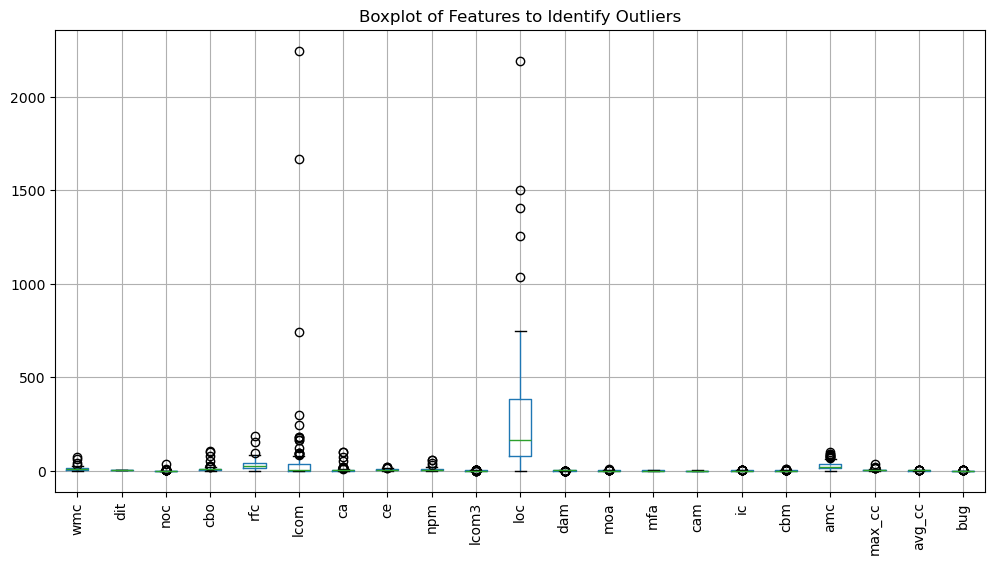

In [9]:
plt.figure(figsize=(12, 6))
df_numeric.boxplot(rot=90)
plt.title("Boxplot of Features to Identify Outliers")
plt.show()

### Feature Scaling
Standardization ensures that all features contribute equally to the model, preventing features with larger ranges from dominating the learning process.

In [10]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df_numeric.drop(columns=["bug"]))
df_scaled = pd.DataFrame(scaled_features, columns=df_numeric.columns[:-1])
df_scaled["bug"] = df_numeric["bug"]

## Model Building
Splitting the dataset ensures the model is evaluated on unseen data, preventing overfitting.

In [11]:
X = df_scaled.drop(columns=["bug"])
y = df_scaled["bug"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

### Handling Class Imbalance with SMOTE
SMOTE is used to oversample the minority class to create a more balanced dataset, improving model performance for defect detection.

In [12]:
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

### Logistic Regression Training
Logistic Regression is a simple, interpretable model for binary classification problems like defect prediction.


In [13]:
logistic_model = LogisticRegression(max_iter=1000, random_state=42)
logistic_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

### Decision Tree Training with Hyperparameter Tuning
Decision Trees can capture complex relationships and are optimized through hyperparameter tuning using GridSearchCV.

In [14]:
param_grid = {
    'max_depth': [3, 5, 10],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}
decision_tree = DecisionTreeClassifier(random_state=42)
grid_search = GridSearchCV(decision_tree, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)
best_tree = grid_search.best_estimator_
print("Best Decision Tree Parameters:", grid_search.best_params_)


Best Decision Tree Parameters: {'criterion': 'gini', 'max_depth': 3, 'min_samples_split': 2}


## Model Predictions

In [15]:
y_pred_logistic = logistic_model.predict(X_test)
y_pred_tree = best_tree.predict(X_test)

## Performance Evaluation
Metrics such as Accuracy, Precision, Recall, and F1 Score provide a comprehensive assessment of model performance.

In [16]:
def evaluate_model(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1 Score": f1_score(y_true, y_pred),
        "Confusion Matrix": confusion_matrix(y_true, y_pred)
    }

logistic_metrics = evaluate_model(y_test, y_pred_logistic)
tree_metrics = evaluate_model(y_test, y_pred_tree)

# Print Results
print("\nLogistic Regression Performance:")
for key, value in logistic_metrics.items():
    print(f"{key}: {value}")

print("\nDecision Tree Performance:")
for key, value in tree_metrics.items():
    print(f"{key}: {value}")

if tree_metrics['F1 Score'] > logistic_metrics['F1 Score']:
    print("Decision Tree performs better in detecting software defects due to higher recall and F1-score.")
else:
    print("Logistic Regression may need class balancing techniques for improved defect detection.")


Logistic Regression Performance:
Accuracy: 0.8333333333333334
Precision: 0.0
Recall: 0.0
F1 Score: 0.0
Confusion Matrix: [[20  2]
 [ 2  0]]

Decision Tree Performance:
Accuracy: 0.8333333333333334
Precision: 0.25
Recall: 0.5
F1 Score: 0.3333333333333333
Confusion Matrix: [[19  3]
 [ 1  1]]
Decision Tree performs better in detecting software defects due to higher recall and F1-score.


## Part 2

### Initialize models
We are using multiple models to compare performance and determine which classifier is most suitable for defect prediction.

In [17]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=3, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

# Store results
results = {}

### Train and evaluate models
Each model is trained and evaluated using key performance metrics to compare their effectiveness.

In [18]:
for name, model in models.items():
    model.fit(X_train_resampled, y_train_resampled)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None
    y_pred = (y_prob > 0.3).astype(int) if y_prob is not None else model.predict(X_test)  # Adjust decision threshold to 0.3
    
    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=1),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "AUC-ROC": roc_auc_score(y_test, y_prob) if y_prob is not None else 0
    }

# Convert results to DataFrame
results_df = pd.DataFrame(results).T
print("\nModel Performance Comparison:")
print(results_df)


Model Performance Comparison:
                     Accuracy  Precision  Recall  F1 Score   AUC-ROC
Logistic Regression  0.500000   0.000000     0.0  0.000000  0.454545
Decision Tree        0.666667   0.000000     0.0  0.000000  0.363636
Random Forest        0.791667   0.200000     0.5  0.285714  0.636364
KNN                  0.541667   0.153846     1.0  0.266667  0.715909


### Plot ROC Curves
The ROC curve visually represents the trade-off between sensitivity (true positive rate) and specificity (false positive rate) for different classifiers.

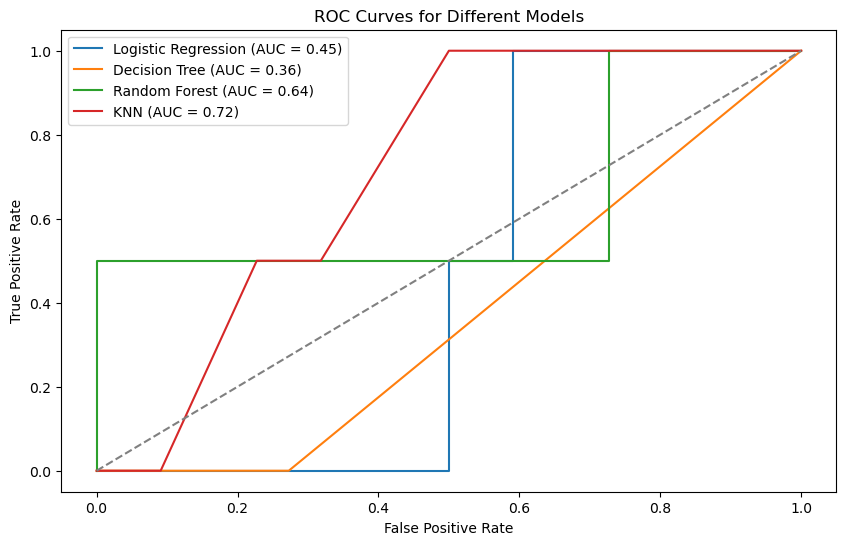

In [19]:
plt.figure(figsize=(10, 6))
for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None
    if y_prob is not None:
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc_score(y_test, y_prob):.2f})")

plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Different Models")
plt.legend()
plt.show()

### Identify Best Model
The model with the highest AUC-ROC score is selected as the best since it demonstrates superior ability to distinguish between defective and non-defective components.

In [20]:
best_model = results_df.sort_values(by="AUC-ROC", ascending=False).index[0]
print(f"\nBest Model: {best_model}")
print("The best model is selected based on the highest AUC-ROC score, as it indicates the model's ability to distinguish between defective and non-defective software components.")



Best Model: KNN
The best model is selected based on the highest AUC-ROC score, as it indicates the model's ability to distinguish between defective and non-defective software components.
